# Data Quality

## import libraries

In [ ]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns


## load data

In [2]:
DATA_PATH = Path("../data/raw/iot_sensor_data.csv")

df = pd.read_csv(DATA_PATH)

df.head()

,timestamp,device_id,location_id,temperature,humidity,co2,airspeed,light,x,y,production_day
0,2026-01-01 00:00:00,DEV_001,LOC_A,23.922834,65.226321,788.858799,0.369537,48.726615,0,0,1
1,2026-01-01 00:01:00,DEV_001,LOC_A,24.386213,62.853460,818.334831,0.367287,51.603935,0,0,1
2,2026-01-01 00:02:00,DEV_001,LOC_A,24.449512,62.602028,817.730583,0.342487,53.247124,0,0,1
3,2026-01-01 00:03:00,DEV_001,LOC_A,23.742381,62.852535,816.128724,0.384030,52.466760,0,0,1
4,2026-01-01 00:04:00,DEV_001,LOC_A,23.920363,63.315598,823.929473,0.337668,52.647733,0,0,1


In [3]:
df.shape

(432000, 11)

In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 432000 entries, 0 to 431999
Data columns (total 11 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   timestamp       432000 non-null  str    
 1   device_id       432000 non-null  str    
 2   location_id     432000 non-null  str    
 3   temperature     431500 non-null  float64
 4   humidity        432000 non-null  float64
 5   co2             432000 non-null  float64
 6   airspeed        432000 non-null  float64
 7   light           432000 non-null  float64
 8   x               432000 non-null  int64  
 9   y               432000 non-null  int64  
 10  production_day  432000 non-null  int64  
dtypes: float64(5), int64(3), str(3)
memory usage: 36.3 MB


In [6]:
df.describe()

,temperature,humidity,co2,airspeed,light,x,y,production_day
count,431500.000000,432000.000000,432000.000000,432000.000000,432000.000000,432000.000000,432000.000000,432000.000000
mean,24.171260,64.804514,802.810142,0.350140,62.729992,5.000000,5.000000,15.500000
std,2.565840,5.868199,136.364130,0.058629,15.716724,4.472141,4.472141,8.655451
min,18.665808,51.783677,487.414473,0.201931,35.215285,0.000000,0.000000,1.000000
25%,21.823593,59.392892,684.298192,0.295853,49.869317,0.000000,0.000000,8.000000
50%,24.175864,64.783766,802.344369,0.350156,54.377031,5.000000,5.000000,15.500000
75%,26.524171,70.209510,920.892723,0.404346,78.106680,10.000000,10.000000,23.000000
max,42.849159,129.937419,2328.916077,0.620076,102.700001,10.000000,10.000000,30.000000


In [10]:
df.describe(include="str")

,timestamp,device_id,location_id
count,432000,432000,432000
unique,43200,10,5
top,2026-01-01 00:00:00,DEV_001,LOC_A
freq,10,43200,86400


In [12]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

In [20]:
df["timestamp"].info()

<class 'pandas.Series'>
RangeIndex: 432000 entries, 0 to 431999
Series name: timestamp
Non-Null Count   Dtype         
--------------   -----         
432000 non-null  datetime64[us]
dtypes: datetime64[us](1)
memory usage: 3.3 MB


## Missing Data

In [21]:
missing = df.isna().sum()

missing

timestamp           0
device_id           0
location_id         0
temperature       500
humidity            0
co2                 0
airspeed            0
light               0
x                   0
y                   0
production_day      0
dtype: int64

In [22]:
missing_rate = (
    df.isna().mean() * 100
).sort_values(ascending=False)

missing_rate

temperature       0.115741
device_id         0.000000
timestamp         0.000000
location_id       0.000000
humidity          0.000000
co2               0.000000
airspeed          0.000000
light             0.000000
x                 0.000000
y                 0.000000
production_day    0.000000
dtype: float64

In [23]:
df[df["temperature"].isna()].head()

,timestamp,device_id,location_id,temperature,humidity,co2,airspeed,light,x,y,production_day
1360,2026-01-01 22:40:00,DEV_001,LOC_A,NaN,65.333502,868.593693,0.291625,52.871014,0,0,1
2777,2026-01-02 22:17:00,DEV_001,LOC_A,NaN,68.209456,933.828085,0.314680,49.798267,0,0,2
2989,2026-01-03 01:49:00,DEV_001,LOC_A,NaN,60.729116,800.089896,0.387526,67.120263,0,0,3
3189,2026-01-03 05:09:00,DEV_001,LOC_A,NaN,56.165737,701.769891,0.442075,89.154787,0,0,3
3226,2026-01-03 05:46:00,DEV_001,LOC_A,NaN,54.951962,665.118179,0.416417,87.519784,0,0,3


In [24]:
df[df["temperature"].isna()]["device_id"].value_counts()

device_id
DEV_010    59
DEV_008    56
DEV_003    54
DEV_007    51
DEV_009    51
DEV_004    50
DEV_005    48
DEV_001    45
DEV_006    44
DEV_002    42
Name: count, dtype: int64

## Uniqueness & Duplicates

In [30]:
duplicate_count = df.duplicated().sum()

duplicate_count

np.int64(0)

In [31]:
key_columns = [
    "timestamp",
    "device_id"
]

duplicate_keys = df.duplicated(
    subset=key_columns
).sum()

duplicate_keys

np.int64(0)

## Validity

In [32]:
invalid_humidity = df[
    (df["humidity"] < 0) | (df["humidity"] > 100)
]

len(invalid_humidity)

50

In [33]:
invalid_humidity[
    ["timestamp", "device_id", "humidity"]
].head()

,timestamp,device_id,humidity
7553,2026-01-06 05:53:00,DEV_001,121.219662
26257,2026-01-19 05:37:00,DEV_001,105.315569
38199,2026-01-27 12:39:00,DEV_001,125.392786
48449,2026-01-04 15:29:00,DEV_002,113.915138
53230,2026-01-07 23:10:00,DEV_002,123.797390


In [34]:
invalid_temperature = df[
    (df["temperature"] < -20) |
    (df["temperature"] > 60)
]

len(invalid_temperature)

0

In [35]:
invalid_co2 = df[
    (df["co2"] < 0)
]

len(invalid_co2)

0

In [36]:
invalid_airspeed = df[
    (df["airspeed"] < 0)
]

len(invalid_airspeed)

0

In [37]:
invalid_light = df[
    (df["light"] < 0)
]

len(invalid_light)

0

In [38]:
quality_summary = pd.DataFrame({
    "check": [
        "Missing values",
        "Duplicate rows",
        "Duplicate device-timestamp",
        "Invalid humidity",
        "Invalid temperature",
        "Invalid CO2",
        "Invalid airspeed",
        "Invalid light",
    ],
    "count": [
        df.isna().sum().sum(),
        df.duplicated().sum(),
        df.duplicated(
            subset=["timestamp", "device_id"]
        ).sum(),
        len(invalid_humidity),
        len(invalid_temperature),
        len(invalid_co2),
        len(invalid_airspeed),
        len(invalid_light),
    ]
})

quality_summary

,check,count
0,Missing values,500
1,Duplicate rows,0
2,Duplicate device-timestamp,0
3,Invalid humidity,50
4,Invalid temperature,0
5,Invalid CO2,0
6,Invalid airspeed,0
7,Invalid light,0


## Timeliness*

In [41]:
df = df.sort_values(
    ["device_id", "timestamp"]
)

df["time_diff"] = (
    df.groupby("device_id")["timestamp"]
    .diff()
)

In [42]:
df["time_diff"].value_counts().head(10)

time_diff
0 days 00:01:00    431990
Name: count, dtype: int64

In [43]:
gaps = df[
    df["time_diff"] > pd.Timedelta(minutes=1)
]

gaps[
    ["device_id", "timestamp", "time_diff"]
].head()

,device_id,timestamp,time_diff


In [44]:
len(gaps)

0

## Metadata Integrity

In [45]:
device_location_counts = (
    df.groupby("device_id")["location_id"]
    .nunique()
)

device_location_counts

device_id
DEV_001    1
DEV_002    1
DEV_003    1
DEV_004    1
DEV_005    1
DEV_006    1
DEV_007    1
DEV_008    1
DEV_009    1
DEV_010    1
Name: location_id, dtype: int64

In [46]:
df.groupby("device_id")[["x", "y"]].nunique()

,x,y
device_id,,
DEV_001,1,1
DEV_002,1,1
DEV_003,1,1
DEV_004,1,1
DEV_005,1,1
DEV_006,1,1
DEV_007,1,1
DEV_008,1,1
DEV_009,1,1


## Visualization

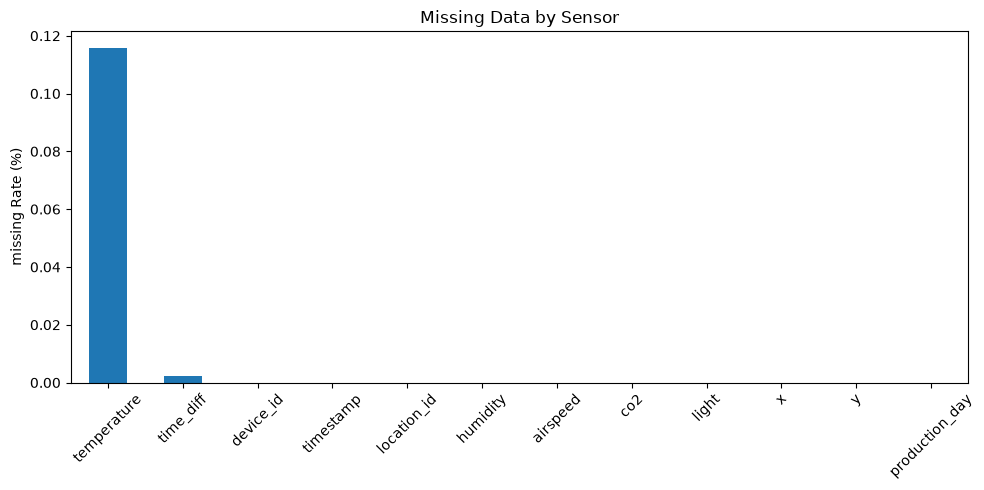

In [48]:
missing_rate_plot = (
    df.isna().mean() * 100
).sort_values(ascending=False)

missing_rate_plot.plot(
    kind="bar",
    figsize=(10, 5)
)

plt.ylabel("missing Rate (%)")
plt.title("Missing Data by Sensor")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

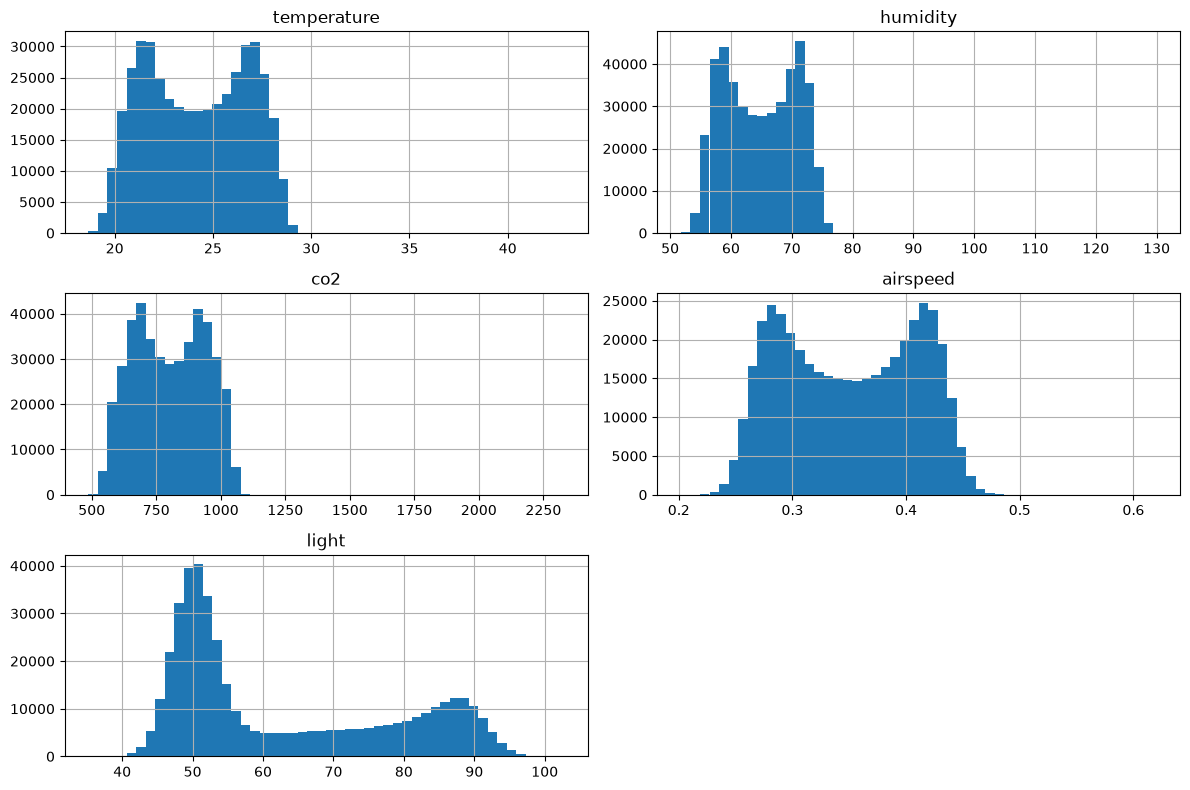

In [49]:
sensor_columns = [
    "temperature",
    "humidity",
    "co2",
    "airspeed",
    "light"
]

df[sensor_columns].hist(
    figsize=(12, 8),
    bins=50
)

plt.tight_layout()
plt.show()